# Comparative Need State Analysis for Ride-Hailing Platforms: A Case Study on PickMe and Uber

In [105]:
import pandas as pd
import numpy as np

In [106]:
# Load the 2 datasets
main_file_path = 'The Main English dataset of final year project.xlsx'
bothoptions_file_path = 'Both PickMe & Uber Option translated data.xlsx'

In [107]:
# Create DataFrames from the Excel files
main_df = pd.read_excel(main_file_path)
both_df = pd.read_excel(bothoptions_file_path)

# DATA PREPROCESSING

#### main_df

In [108]:
# Display the first few rows of the English dataset to understand its structure
main_df.head()

,Timestamp,Age,Gender,District,Monthly_Income,RideHailing_App,P_PickMePreference,P_PickMePurpose,P_PickMeFrequency,P_PickMeVehicle,...,B_Preference,B_SwitchingFrequency,B_Purpose,B_Frequency,B_Time,B_PickMeVehicle,B_UberVehicle,B_PaymentMethod,B_PickMePass,B_UberOne
0,2025-01-03 08:21:52.322,18-25,Male,Colombo,"Less than LKR 50,000",PickMe only,"PickMe has shorter wait times, Better availabi...","Social or leisure activities, Commuting to wor...",Weekly,"Tuk, Bike",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-03 10:02:26.294,18-25,Female,Gampaha,"LKR 300,000 or more",Both PickMe & Uber,NaN,NaN,NaN,NaN,...,Better driver availability,Always,Comfort and convenience,Occasionally,Don't have a specific time,Tuk,"Tuk, Zip",Both cash & card,No,No
2,2025-01-03 12:14:35.376,18-25,Male,Colombo,Prefer not to say,Both PickMe & Uber,NaN,NaN,NaN,NaN,...,"To compare prices, Better driver availability,...",Often,"Comfort and convenience, Commuting to work, He...",Monthly,"Office Hours (7 AM - 10 AM & 4 PM - 7 PM), Don...","Tuk, Bike",Tuk,Cash,No,No
3,2025-01-03 13:02:46.370,18-25,Female,Colombo,"Less than LKR 50,000",PickMe only,Better availability in my area,Comfort and convenience,Weekly,Tuk,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-03 13:21:55.893,18-25,Female,Colombo,"LKR 200,000 – 299,999",Personal car,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [109]:
# Get the row count of the dataset
row_count = len(main_df)
print(f"The dataset contains {row_count} rows.")

The dataset contains 428 rows.


In [110]:
main_df.dtypes

Timestamp               datetime64[ns]
Age                             object
Gender                          object
District                        object
Monthly_Income                  object
RideHailing_App                 object
P_PickMePreference              object
P_PickMePurpose                 object
P_PickMeFrequency               object
P_PickMeVehicle                 object
P_PickMeTime                    object
P_PickMePayment                 object
P_PickMePass                    object
U_UberPreference                object
U_UberPurpose                   object
U_UberFrequency                 object
U_UberVehicle                   object
U_UberTime                      object
U_UberPayment                   object
U_UberOne                       object
B_Preference                    object
B_SwitchingFrequency            object
B_Purpose                       object
B_Frequency                     object
B_Time                          object
B_PickMeVehicle          

In [111]:
# Remove duplicate rows, if any
main_df.drop_duplicates(inplace=True)

In [112]:
# Get the row count of the dataset
row_count = len(main_df)
print(f"The dataset contains {row_count} rows.")

The dataset contains 428 rows.


In [113]:
# Drop rows where all elements are missing
main_df.dropna(how='all', inplace=True)

In [114]:
# Get the row count of the dataset
row_count = len(main_df)
print(f"The dataset contains {row_count} rows.")

The dataset contains 428 rows.


In [115]:
# Count missing values for each column
missing_values = main_df.isnull().sum()

# Display the missing value count
print("Missing value count by column:")
print(missing_values)

Missing value count by column:
Timestamp                 0
Age                       0
Gender                    0
District                  0
Monthly_Income            0
RideHailing_App           0
P_PickMePreference      250
P_PickMePurpose         250
P_PickMeFrequency       250
P_PickMeVehicle         250
P_PickMeTime            250
P_PickMePayment         250
P_PickMePass            250
U_UberPreference        384
U_UberPurpose           384
U_UberFrequency         384
U_UberVehicle           384
U_UberTime              384
U_UberPayment           384
U_UberOne               384
B_Preference            227
B_SwitchingFrequency    227
B_Purpose               227
B_Frequency             227
B_Time                  227
B_PickMeVehicle         227
B_UberVehicle           227
B_PaymentMethod         227
B_PickMePass            227
B_UberOne               227
dtype: int64


In [116]:
# Remove the Timestamp column
main_df = main_df.drop(columns=['Timestamp'])

# Verify the changes
main_df.head()

,Age,Gender,District,Monthly_Income,RideHailing_App,P_PickMePreference,P_PickMePurpose,P_PickMeFrequency,P_PickMeVehicle,P_PickMeTime,...,B_Preference,B_SwitchingFrequency,B_Purpose,B_Frequency,B_Time,B_PickMeVehicle,B_UberVehicle,B_PaymentMethod,B_PickMePass,B_UberOne
0,18-25,Male,Colombo,"Less than LKR 50,000",PickMe only,"PickMe has shorter wait times, Better availabi...","Social or leisure activities, Commuting to wor...",Weekly,"Tuk, Bike",Office Hours (7 AM - 10 AM & 4 PM - 7 PM),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18-25,Female,Gampaha,"LKR 300,000 or more",Both PickMe & Uber,NaN,NaN,NaN,NaN,NaN,...,Better driver availability,Always,Comfort and convenience,Occasionally,Don't have a specific time,Tuk,"Tuk, Zip",Both cash & card,No,No
2,18-25,Male,Colombo,Prefer not to say,Both PickMe & Uber,NaN,NaN,NaN,NaN,NaN,...,"To compare prices, Better driver availability,...",Often,"Comfort and convenience, Commuting to work, He...",Monthly,"Office Hours (7 AM - 10 AM & 4 PM - 7 PM), Don...","Tuk, Bike",Tuk,Cash,No,No
3,18-25,Female,Colombo,"Less than LKR 50,000",PickMe only,Better availability in my area,Comfort and convenience,Weekly,Tuk,Evening (4 PM - 7 PM),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,18-25,Female,Colombo,"LKR 200,000 – 299,999",Personal car,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [117]:
# Filter rows for Colombo district
colombo_df = main_df[main_df['District'] == 'Colombo']

# Get the row count of the dataset
row_count = len(colombo_df)
print(f"The dataset contains {row_count} rows.")

The dataset contains 355 rows.


In [118]:
# Convert all column names to lowercase
colombo_df.columns = colombo_df.columns.str.lower()

In [119]:
# Standardize column names (remove leading/trailing spaces and replace multiple spaces with a single space)
colombo_df.columns = colombo_df.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

# Standardize string values in all object-type columns
colombo_df = colombo_df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [120]:
# Convert all object-type (string) column values to lowercase
colombo_df = colombo_df.apply(lambda x: x.str.lower() if x.dtype == "object" else x)

In [121]:
colombo_df.head()

,age,gender,district,monthly_income,ridehailing_app,p_pickmepreference,p_pickmepurpose,p_pickmefrequency,p_pickmevehicle,p_pickmetime,...,b_preference,b_switchingfrequency,b_purpose,b_frequency,b_time,b_pickmevehicle,b_ubervehicle,b_paymentmethod,b_pickmepass,b_uberone
0,18-25,male,colombo,"less than lkr 50,000",pickme only,"pickme has shorter wait times, better availabi...","social or leisure activities, commuting to wor...",weekly,"tuk, bike",office hours (7 am - 10 am & 4 pm - 7 pm),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,18-25,male,colombo,prefer not to say,both pickme & uber,NaN,NaN,NaN,NaN,NaN,...,"to compare prices, better driver availability,...",often,"comfort and convenience, commuting to work, he...",monthly,"office hours (7 am - 10 am & 4 pm - 7 pm), don...","tuk, bike",tuk,cash,no,no
3,18-25,female,colombo,"less than lkr 50,000",pickme only,better availability in my area,comfort and convenience,weekly,tuk,evening (4 pm - 7 pm),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,18-25,female,colombo,"lkr 200,000 – 299,999",personal car,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,36-45,female,colombo,prefer not to say,pickme only,i’ve had bad experiences with uber,"comfort and convenience, lack of public transp...",weekly,"tuk, car, flex",don't have a specific time,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [122]:
colombo_df.columns

Index(['age', 'gender', 'district', 'monthly_income', 'ridehailing_app',
       'p_pickmepreference', 'p_pickmepurpose', 'p_pickmefrequency',
       'p_pickmevehicle', 'p_pickmetime', 'p_pickmepayment', 'p_pickmepass',
       'u_uberpreference', 'u_uberpurpose', 'u_uberfrequency', 'u_ubervehicle',
       'u_ubertime', 'u_uberpayment', 'u_uberone', 'b_preference',
       'b_switchingfrequency', 'b_purpose', 'b_frequency', 'b_time',
       'b_pickmevehicle', 'b_ubervehicle', 'b_paymentmethod', 'b_pickmepass',
       'b_uberone'],
      dtype='object')

In [123]:
# Print the unique values in the RideHailing_App column
print("Unique values in the RideHailing_App column:")
for index, value in enumerate(colombo_df['ridehailing_app'].unique(), start=1):
    print(f"{index}. {value}")

Unique values in the RideHailing_App column:
1. pickme only
2. both pickme & uber
3. personal car
4. uber only
5. personal transport


In [124]:
# List of values to remove
values_to_remove = ['personal car', 'personal transport']

# Filter out rows where RideHailing_App contains unwanted values
colombo_df = colombo_df[~colombo_df['ridehailing_app'].isin(values_to_remove)]

# Verify the result
print("Unique values in the RideHailing_App column:")
for index, value in enumerate(colombo_df['ridehailing_app'].unique(), start=1):
    print(f"{index}. {value}")

Unique values in the RideHailing_App column:
1. pickme only
2. both pickme & uber
3. uber only


In [125]:
# Get the row count of the dataset
row_count = len(colombo_df)
print(f"The dataset contains {row_count} rows.")

The dataset contains 353 rows.


In [126]:
colombo_df.head()

,age,gender,district,monthly_income,ridehailing_app,p_pickmepreference,p_pickmepurpose,p_pickmefrequency,p_pickmevehicle,p_pickmetime,...,b_preference,b_switchingfrequency,b_purpose,b_frequency,b_time,b_pickmevehicle,b_ubervehicle,b_paymentmethod,b_pickmepass,b_uberone
0,18-25,male,colombo,"less than lkr 50,000",pickme only,"pickme has shorter wait times, better availabi...","social or leisure activities, commuting to wor...",weekly,"tuk, bike",office hours (7 am - 10 am & 4 pm - 7 pm),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,18-25,male,colombo,prefer not to say,both pickme & uber,NaN,NaN,NaN,NaN,NaN,...,"to compare prices, better driver availability,...",often,"comfort and convenience, commuting to work, he...",monthly,"office hours (7 am - 10 am & 4 pm - 7 pm), don...","tuk, bike",tuk,cash,no,no
3,18-25,female,colombo,"less than lkr 50,000",pickme only,better availability in my area,comfort and convenience,weekly,tuk,evening (4 pm - 7 pm),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,36-45,female,colombo,prefer not to say,pickme only,i’ve had bad experiences with uber,"comfort and convenience, lack of public transp...",weekly,"tuk, car, flex",don't have a specific time,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,26-35,male,colombo,"less than lkr 50,000",both pickme & uber,NaN,NaN,NaN,NaN,NaN,...,"to compare prices, when one app has service do...",often,"comfort and convenience, lack of public transp...",monthly,don't have a specific time,"tuk, bike, car, flex","tuk, zip, minivan",both cash & card,no,no


#### both_df

In [127]:
# Display the first few rows of the English dataset to understand its structure
both_df.head()

,Timestamp,Age,Gender,District,Monthly_Income,RideHailing_App,P_PickMePreference,P_PickMePurpose,P_PickMeFrequency,P_PickMeVehicle,...,B_Preference,B_SwitchingFrequency,B_Purpose,B_Frequency,B_Time,B_PickMeVehicle,B_UberVehicle,B_PaymentMethod,B_PickMePass,B_UberOne
0,2025-02-02 20:40:33.834,18-25,Male,Colombo,"LKR 50,000 – 99,999",Both PickMe & Uber,NaN,NaN,NaN,NaN,...,Better driver availability,Often,"Comfort and convenience, Lack of public transp...",Weekly,NaN,Tuk,"Tuk, Moto",Both cash & card,Yes,No
1,2025-02-02 20:42:04.998,18-25,Female,Colombo,"LKR 50,000 – 99,999",Both PickMe & Uber,NaN,NaN,NaN,NaN,...,Urgency or convenience,Rarely,Emergencies,Occasionally,NaN,Tuk,Tuk,Both cash & card,No,No
2,2025-02-02 20:43:36.169,18-25,Female,Colombo,"LKR 100,000 – 149,999",Both PickMe & Uber,NaN,NaN,NaN,NaN,...,"To compare prices, Better driver availability,...",Often,"Lack of public transport options, Special Occa...",Occasionally,NaN,Tuk,Tuk,Cash,No,No
3,2025-02-02 20:45:08.688,Under 18,Female,Colombo,"Less than LKR 50,000",Both PickMe & Uber,NaN,NaN,NaN,NaN,...,"Better driver availability, Driver quality dif...",Often,"Comfort and convenience, Shopping errands, Sch...",Monthly,NaN,"Tuk, Bike",Tuk,Cash,No,No
4,2025-02-02 20:46:04.411,18-25,Female,Colombo,"Less than LKR 50,000",Both PickMe & Uber,NaN,NaN,NaN,NaN,...,When one app has service downtime,Rarely,Emergencies,Occasionally,NaN,Tuk,Tuk,Cash,No,No


In [128]:
# Get the row count of the dataset
row_count = len(both_df)
print(f"The dataset contains {row_count} rows.")

The dataset contains 31 rows.


In [129]:
both_df.dtypes

Timestamp               datetime64[ns]
Age                             object
Gender                          object
District                        object
Monthly_Income                  object
RideHailing_App                 object
P_PickMePreference             float64
P_PickMePurpose                float64
P_PickMeFrequency              float64
P_PickMeVehicle                float64
P_PickMeTime                   float64
P_PickMePayment                float64
P_PickMePass                   float64
U_UberPreference               float64
U_UberPurpose                  float64
U_UberFrequency                float64
U_UberVehicle                  float64
U_UberTime                     float64
U_UberPayment                  float64
U_UberOne                      float64
B_Preference                    object
B_SwitchingFrequency            object
B_Purpose                       object
B_Frequency                     object
B_Time                         float64
B_PickMeVehicle          

In [130]:
# Remove duplicate rows, if any
both_df.drop_duplicates(inplace=True)

In [131]:
# Get the row count of the dataset
row_count = len(both_df)
print(f"The dataset contains {row_count} rows.")

The dataset contains 31 rows.


In [132]:
# Drop rows where all elements are missing
both_df.dropna(how='all', inplace=True)

In [133]:
# Get the row count of the dataset
row_count = len(both_df)
print(f"The dataset contains {row_count} rows.")

The dataset contains 31 rows.


In [134]:
# Count missing values for each column
missing_values = both_df.isnull().sum()

# Display the missing value count
print("Missing value count by column:")
print(missing_values)

Missing value count by column:
Timestamp                0
Age                      0
Gender                   0
District                 0
Monthly_Income           0
RideHailing_App          0
P_PickMePreference      31
P_PickMePurpose         31
P_PickMeFrequency       31
P_PickMeVehicle         31
P_PickMeTime            31
P_PickMePayment         31
P_PickMePass            31
U_UberPreference        31
U_UberPurpose           31
U_UberFrequency         31
U_UberVehicle           31
U_UberTime              31
U_UberPayment           31
U_UberOne               31
B_Preference             0
B_SwitchingFrequency     0
B_Purpose                0
B_Frequency              0
B_Time                  31
B_PickMeVehicle          0
B_UberVehicle            0
B_PaymentMethod          0
B_PickMePass             0
B_UberOne                0
dtype: int64


In [135]:
# Remove the Timestamp column
both_df = both_df.drop(columns=['Timestamp'])

# Verify the changes
main_df.head()

,Age,Gender,District,Monthly_Income,RideHailing_App,P_PickMePreference,P_PickMePurpose,P_PickMeFrequency,P_PickMeVehicle,P_PickMeTime,...,B_Preference,B_SwitchingFrequency,B_Purpose,B_Frequency,B_Time,B_PickMeVehicle,B_UberVehicle,B_PaymentMethod,B_PickMePass,B_UberOne
0,18-25,Male,Colombo,"Less than LKR 50,000",PickMe only,"PickMe has shorter wait times, Better availabi...","Social or leisure activities, Commuting to wor...",Weekly,"Tuk, Bike",Office Hours (7 AM - 10 AM & 4 PM - 7 PM),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18-25,Female,Gampaha,"LKR 300,000 or more",Both PickMe & Uber,NaN,NaN,NaN,NaN,NaN,...,Better driver availability,Always,Comfort and convenience,Occasionally,Don't have a specific time,Tuk,"Tuk, Zip",Both cash & card,No,No
2,18-25,Male,Colombo,Prefer not to say,Both PickMe & Uber,NaN,NaN,NaN,NaN,NaN,...,"To compare prices, Better driver availability,...",Often,"Comfort and convenience, Commuting to work, He...",Monthly,"Office Hours (7 AM - 10 AM & 4 PM - 7 PM), Don...","Tuk, Bike",Tuk,Cash,No,No
3,18-25,Female,Colombo,"Less than LKR 50,000",PickMe only,Better availability in my area,Comfort and convenience,Weekly,Tuk,Evening (4 PM - 7 PM),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,18-25,Female,Colombo,"LKR 200,000 – 299,999",Personal car,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [136]:
# Filter rows for Colombo district
colombo_df2 = both_df[both_df['District'] == 'Colombo']

# Get the row count of the dataset
row_count = len(colombo_df2)
print(f"The dataset contains {row_count} rows.")

The dataset contains 31 rows.


In [137]:
# Convert all column names to lowercase
colombo_df2.columns = colombo_df2.columns.str.lower()

In [138]:
# Standardize column names (remove leading/trailing spaces and replace multiple spaces with a single space)
colombo_df2.columns = colombo_df2.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

# Standardize string values in all object-type columns
colombo_df2 = colombo_df2.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [139]:
# Convert all object-type (string) column values to lowercase
colombo_df2 = colombo_df2.apply(lambda x: x.str.lower() if x.dtype == "object" else x)

In [140]:
colombo_df2.head()

,age,gender,district,monthly_income,ridehailing_app,p_pickmepreference,p_pickmepurpose,p_pickmefrequency,p_pickmevehicle,p_pickmetime,...,b_preference,b_switchingfrequency,b_purpose,b_frequency,b_time,b_pickmevehicle,b_ubervehicle,b_paymentmethod,b_pickmepass,b_uberone
0,18-25,male,colombo,"lkr 50,000 – 99,999",both pickme & uber,NaN,NaN,NaN,NaN,NaN,...,better driver availability,often,"comfort and convenience, lack of public transp...",weekly,NaN,tuk,"tuk, moto",both cash & card,yes,no
1,18-25,female,colombo,"lkr 50,000 – 99,999",both pickme & uber,NaN,NaN,NaN,NaN,NaN,...,urgency or convenience,rarely,emergencies,occasionally,NaN,tuk,tuk,both cash & card,no,no
2,18-25,female,colombo,"lkr 100,000 – 149,999",both pickme & uber,NaN,NaN,NaN,NaN,NaN,...,"to compare prices, better driver availability,...",often,"lack of public transport options, special occa...",occasionally,NaN,tuk,tuk,cash,no,no
3,under 18,female,colombo,"less than lkr 50,000",both pickme & uber,NaN,NaN,NaN,NaN,NaN,...,"better driver availability, driver quality dif...",often,"comfort and convenience, shopping errands, sch...",monthly,NaN,"tuk, bike",tuk,cash,no,no
4,18-25,female,colombo,"less than lkr 50,000",both pickme & uber,NaN,NaN,NaN,NaN,NaN,...,when one app has service downtime,rarely,emergencies,occasionally,NaN,tuk,tuk,cash,no,no


In [141]:
colombo_df2.columns

Index(['age', 'gender', 'district', 'monthly_income', 'ridehailing_app',
       'p_pickmepreference', 'p_pickmepurpose', 'p_pickmefrequency',
       'p_pickmevehicle', 'p_pickmetime', 'p_pickmepayment', 'p_pickmepass',
       'u_uberpreference', 'u_uberpurpose', 'u_uberfrequency', 'u_ubervehicle',
       'u_ubertime', 'u_uberpayment', 'u_uberone', 'b_preference',
       'b_switchingfrequency', 'b_purpose', 'b_frequency', 'b_time',
       'b_pickmevehicle', 'b_ubervehicle', 'b_paymentmethod', 'b_pickmepass',
       'b_uberone'],
      dtype='object')

In [142]:
# Print the unique values in the RideHailing_App column
print("Unique values in the RideHailing_App column:")
for index, value in enumerate(colombo_df2['ridehailing_app'].unique(), start=1):
    print(f"{index}. {value}")

Unique values in the RideHailing_App column:
1. both pickme & uber


### Imputation of missing values in b_time column in both_df

In [143]:
# Filter out rows where RideHailing_App is "both pickme & uber"
colombo_df_both = colombo_df[colombo_df["ridehailing_app"] == "both pickme & uber"]

# Get the row count of the dataset
row_count = len(colombo_df_both)
print(f"The dataset contains {row_count} rows.")

The dataset contains 165 rows.


In [144]:
colombo_df_both.head()

,age,gender,district,monthly_income,ridehailing_app,p_pickmepreference,p_pickmepurpose,p_pickmefrequency,p_pickmevehicle,p_pickmetime,...,b_preference,b_switchingfrequency,b_purpose,b_frequency,b_time,b_pickmevehicle,b_ubervehicle,b_paymentmethod,b_pickmepass,b_uberone
2,18-25,male,colombo,prefer not to say,both pickme & uber,NaN,NaN,NaN,NaN,NaN,...,"to compare prices, better driver availability,...",often,"comfort and convenience, commuting to work, he...",monthly,"office hours (7 am - 10 am & 4 pm - 7 pm), don...","tuk, bike",tuk,cash,no,no
6,26-35,male,colombo,"less than lkr 50,000",both pickme & uber,NaN,NaN,NaN,NaN,NaN,...,"to compare prices, when one app has service do...",often,"comfort and convenience, lack of public transp...",monthly,don't have a specific time,"tuk, bike, car, flex","tuk, zip, minivan",both cash & card,no,no
14,46-55,male,colombo,"lkr 100,000 – 149,999",both pickme & uber,NaN,NaN,NaN,NaN,NaN,...,"to compare prices, driver quality differences",often,"comfort and convenience, lack of public transp...",daily,"evening (4 pm - 7 pm), late night (10 pm - 3 am)","bike, car","tuk, minivan",cash,no,no
16,36-45,male,colombo,"lkr 150,000 – 199,999",both pickme & uber,NaN,NaN,NaN,NaN,NaN,...,better driver availability,rarely,"comfort and convenience, social or leisure act...",monthly,"morning (7 am - 10 am), late night (10 pm - 3 ...","tuk, car","tuk, zip",cash,no,no
24,18-25,male,colombo,"lkr 200,000 – 299,999",both pickme & uber,NaN,NaN,NaN,NaN,NaN,...,"better driver availability, specific features ...",rarely,comfort and convenience,daily,"evening (4 pm - 7 pm), late night (10 pm - 3 am)",tuk,tuk,card,no,no


In [145]:
# # Define file paths for exporting CSVs
# colombo_df2_csv_path = "colombo_df2.csv"
# colombo_df_both_csv_path = "colombo_df_both.csv"

# # Save the dataframes as CSV files
# colombo_df2.to_csv(colombo_df2_csv_path, index=False)
# # colombo_df_both.to_csv(colombo_df_both_csv_path, index=False)

In [146]:
# Select relevant categorical features for matching
matching_columns = ["b_purpose", "b_frequency"]

# Create a filtered dataset from colombo_df_both for matching
filtered_both_df = colombo_df_both.dropna(subset=["b_time"])

In [147]:
# Exact Match Imputation
def exact_match_imputation(row):
    if pd.isna(row["b_time"]):
        match = filtered_both_df[(filtered_both_df[matching_columns] == row[matching_columns]).all(axis=1)]
        if not match.empty:
            return match["b_time"].mode()[0]  # Return the most frequent b_time from matches
    return row["b_time"]

# Apply exact match imputation
colombo_df2["b_time"] = colombo_df2.apply(exact_match_imputation, axis=1)

# Check if Partial Match Imputation is needed
remaining_missing_after_imputation = colombo_df2["b_time"].isna().sum()
remaining_missing_after_imputation

17

In [148]:
# Partial Match Imputation (If missing values remain)
remaining_missing = colombo_df2["b_time"].isna().sum()

if remaining_missing > 0:
    for col in matching_columns:
        colombo_df2["b_time"].fillna(
            colombo_df2.groupby(col)["b_time"].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
            inplace=True
        )

In [149]:
# Check if Machine Learning is needed
remaining_missing_after_rules = colombo_df2["b_time"].isna().sum()
remaining_missing_after_rules

2

In [150]:
print("Unique values in the b_time column with their counts:")
b_time_counts = colombo_df2['b_time'].value_counts()

for index, (value, count) in enumerate(b_time_counts.items(), start=1):
    print(f"{index}. {value} - {count} occurrences")

Unique values in the b_time column with their counts:
1. don't have a specific time - 27 occurrences
2. office hours (7 am - 10 am & 4 pm - 7 pm), late night (10 pm - 3 am) - 1 occurrences
3. school hours (6 am- 7 am & 1 pm - 3 pm) - 1 occurrences


In [151]:
# Define the mode value
mode_value = "don't have a specific time"

# Fill missing values in the 'b_time' column with the mode value
colombo_df2["b_time"].fillna(mode_value, inplace=True)

# Verify if NaNs are filled
remaining_missing_after_fill = colombo_df2["b_time"].isna().sum()
print("Remaining missing values after filling:", remaining_missing_after_fill)

Remaining missing values after filling: 0


In [152]:
# Append colombo_df2_new to colombo_df
colombo_df_combined = pd.concat([colombo_df2, colombo_df], ignore_index=True)

# Reset index to maintain a clean structure
colombo_df_combined.reset_index(drop=True, inplace=True)

In [153]:
# Get the row count of the dataset
row_count = len(colombo_df_combined)
print(f"The dataset contains {row_count} rows.")

The dataset contains 384 rows.


In [154]:
# Add a customerid column as the first column
colombo_df_combined.insert(0, "customerid", range(1, len(colombo_df_combined) + 1))
colombo_df_combined.head()

,customerid,age,gender,district,monthly_income,ridehailing_app,p_pickmepreference,p_pickmepurpose,p_pickmefrequency,p_pickmevehicle,...,b_preference,b_switchingfrequency,b_purpose,b_frequency,b_time,b_pickmevehicle,b_ubervehicle,b_paymentmethod,b_pickmepass,b_uberone
0,1,18-25,male,colombo,"lkr 50,000 – 99,999",both pickme & uber,NaN,NaN,NaN,NaN,...,better driver availability,often,"comfort and convenience, lack of public transp...",weekly,don't have a specific time,tuk,"tuk, moto",both cash & card,yes,no
1,2,18-25,female,colombo,"lkr 50,000 – 99,999",both pickme & uber,NaN,NaN,NaN,NaN,...,urgency or convenience,rarely,emergencies,occasionally,don't have a specific time,tuk,tuk,both cash & card,no,no
2,3,18-25,female,colombo,"lkr 100,000 – 149,999",both pickme & uber,NaN,NaN,NaN,NaN,...,"to compare prices, better driver availability,...",often,"lack of public transport options, special occa...",occasionally,don't have a specific time,tuk,tuk,cash,no,no
3,4,under 18,female,colombo,"less than lkr 50,000",both pickme & uber,NaN,NaN,NaN,NaN,...,"better driver availability, driver quality dif...",often,"comfort and convenience, shopping errands, sch...",monthly,don't have a specific time,"tuk, bike",tuk,cash,no,no
4,5,18-25,female,colombo,"less than lkr 50,000",both pickme & uber,NaN,NaN,NaN,NaN,...,when one app has service downtime,rarely,emergencies,occasionally,don't have a specific time,tuk,tuk,cash,no,no


### Final preprocessing

In [155]:
# Apply transformation: If "don't have a specific time" appears with other values, replace it with just "don't have a specific time"
colombo_df_combined["b_time"] = colombo_df_combined["b_time"].apply(
    lambda x: "don't have a specific time" if "don't have a specific time" in str(x) else x
)

In [156]:
# Print the unique values in the b_time column
print("Unique values in the b_time column:")
for index, value in enumerate(colombo_df_combined['b_time'].unique(), start=1):
    print(f"{index}. {value}")

Unique values in the b_time column:
1. don't have a specific time
2. office hours (7 am - 10 am & 4 pm - 7 pm), late night (10 pm - 3 am)
3. school hours (6 am- 7 am & 1 pm - 3 pm)
4. nan
5. evening (4 pm - 7 pm), late night (10 pm - 3 am)
6. morning (7 am - 10 am), late night (10 pm - 3 am), school hours (6 am- 7 am & 1 pm - 3 pm)
7. office hours (7 am - 10 am & 4 pm - 7 pm)
8. office hours (7 am - 10 am & 4 pm - 7 pm), evening (4 pm - 7 pm)
9. evening (4 pm - 7 pm)
10. late night (10 pm - 3 am)
11. morning (7 am - 10 am)
12. morning (7 am - 10 am), evening (4 pm - 7 pm)
13. morning (7 am - 10 am), office hours (7 am - 10 am & 4 pm - 7 pm), late night (10 pm - 3 am)
14. morning (7 am - 10 am), school hours (6 am- 7 am & 1 pm - 3 pm)
15. morning (7 am - 10 am), late night (10 pm - 3 am)
16. morning (7 am - 10 am), office hours (7 am - 10 am & 4 pm - 7 pm)
17. morning (7 am - 10 am), evening (4 pm - 7 pm), late night (10 pm - 3 am)
18. office hours (7 am - 10 am & 4 pm - 7 pm), evening 

In [157]:
# Remove extra spaces and unnecessary commas just in case
colombo_df_combined = colombo_df_combined.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
colombo_df_combined = colombo_df_combined.apply(lambda x: x.str.replace(r'\s+', ' ', regex=True) if x.dtype == "object" else x)
colombo_df_combined = colombo_df_combined.apply(lambda x: x.str.replace(',+', ',', regex=True) if x.dtype == "object" else x)

# Rename the dataframe
preprocessed_data = colombo_df_combined.copy()

In [158]:
# Define file paths for exporting CSVs
preprocessed_data_csv_path = "preprocessed_data2.csv"

# Save the dataframes as CSV files
preprocessed_data.to_csv(preprocessed_data_csv_path, index=False)

# EXPLORATORY DATA ANALYSIS

In [159]:
preprocessed_data.shape

(384, 30)

In [160]:
preprocessed_data.describe

<bound method NDFrame.describe of      customerid       age  gender district         monthly_income  \
0             1     18-25    male  colombo    lkr 50,000 – 99,999   
1             2     18-25  female  colombo    lkr 50,000 – 99,999   
2             3     18-25  female  colombo  lkr 100,000 – 149,999   
3             4  under 18  female  colombo   less than lkr 50,000   
4             5     18-25  female  colombo   less than lkr 50,000   
..          ...       ...     ...      ...                    ...   
379         380     18-25  female  colombo    lkr 50,000 – 99,999   
380         381     26-35  female  colombo  lkr 100,000 – 149,999   
381         382     18-25  female  colombo   less than lkr 50,000   
382         383     26-35    male  colombo    lkr 50,000 – 99,999   
383         384     26-35    male  colombo    lkr 50,000 – 99,999   

        ridehailing_app                                 p_pickmepreference  \
0    both pickme & uber                                    

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns

In [162]:
# Set the style for better visuals
sns.set_style("whitegrid")

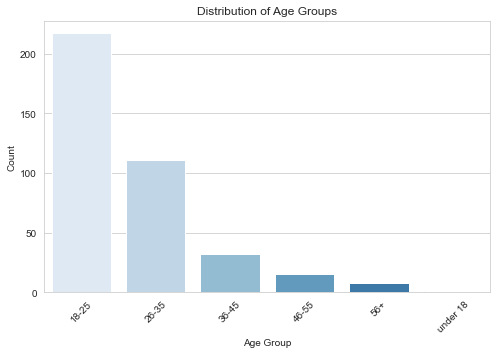

In [163]:
# Age Groups Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=preprocessed_data, x="age", order=preprocessed_data["age"].value_counts().index, palette="Blues")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.title("Distribution of Age Groups")
plt.xticks(rotation=45)
plt.savefig("age_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

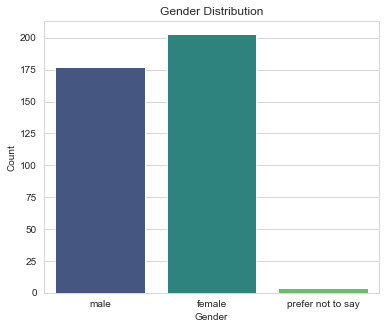

In [164]:
# Gender Distribution
plt.figure(figsize=(6, 5))
sns.countplot(data=preprocessed_data, x="gender", palette="viridis")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender Distribution")
plt.savefig("gender_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

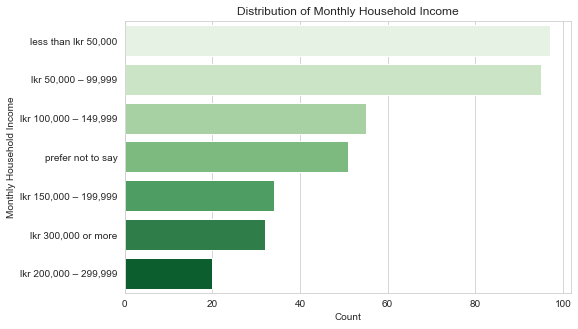

In [165]:
# Monthly Household Income Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=preprocessed_data, y="monthly_income", order=preprocessed_data["monthly_income"].value_counts().index, palette="Greens")
plt.ylabel("Monthly Household Income")
plt.xlabel("Count")
plt.title("Distribution of Monthly Household Income")
plt.savefig("householdincome_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

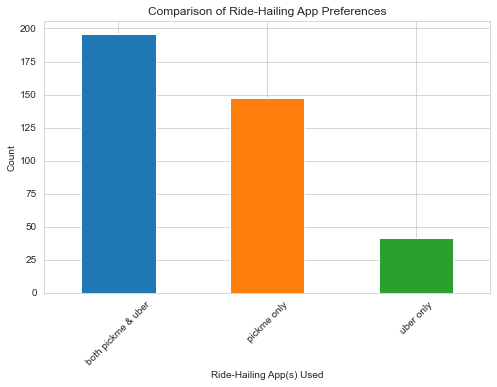

In [166]:
# Ride-Hailing App Preferences Breakdown
ride_hailing_counts = preprocessed_data["ridehailing_app"].value_counts()

plt.figure(figsize=(8, 5))
ride_hailing_counts.plot(kind="bar", color=["#1f77b4", "#ff7f0e", "#2ca02c"])
plt.xlabel("Ride-Hailing App(s) Used")
plt.ylabel("Count")
plt.title("Comparison of Ride-Hailing App Preferences")
plt.xticks(rotation=45)
plt.savefig("platform_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# k-mode Clustering 

In [167]:
# Fill missing values with "Not Applicable"
df_for_clustering = preprocessed_data.fillna("Not Applicable")
df_for_clustering.head()

,customerid,age,gender,district,monthly_income,ridehailing_app,p_pickmepreference,p_pickmepurpose,p_pickmefrequency,p_pickmevehicle,...,b_preference,b_switchingfrequency,b_purpose,b_frequency,b_time,b_pickmevehicle,b_ubervehicle,b_paymentmethod,b_pickmepass,b_uberone
0,1,18-25,male,colombo,"lkr 50,000 – 99,999",both pickme & uber,Not Applicable,Not Applicable,Not Applicable,Not Applicable,...,better driver availability,often,"comfort and convenience, lack of public transp...",weekly,don't have a specific time,tuk,"tuk, moto",both cash & card,yes,no
1,2,18-25,female,colombo,"lkr 50,000 – 99,999",both pickme & uber,Not Applicable,Not Applicable,Not Applicable,Not Applicable,...,urgency or convenience,rarely,emergencies,occasionally,don't have a specific time,tuk,tuk,both cash & card,no,no
2,3,18-25,female,colombo,"lkr 100,000 – 149,999",both pickme & uber,Not Applicable,Not Applicable,Not Applicable,Not Applicable,...,"to compare prices, better driver availability,...",often,"lack of public transport options, special occa...",occasionally,don't have a specific time,tuk,tuk,cash,no,no
3,4,under 18,female,colombo,"less than lkr 50,000",both pickme & uber,Not Applicable,Not Applicable,Not Applicable,Not Applicable,...,"better driver availability, driver quality dif...",often,"comfort and convenience, shopping errands, sch...",monthly,don't have a specific time,"tuk, bike",tuk,cash,no,no
4,5,18-25,female,colombo,"less than lkr 50,000",both pickme & uber,Not Applicable,Not Applicable,Not Applicable,Not Applicable,...,when one app has service downtime,rarely,emergencies,occasionally,don't have a specific time,tuk,tuk,cash,no,no


In [168]:
# Drop CustomerID as it's not relevant for clustering
df_for_clustering = df_for_clustering.drop(columns=["customerid"])

In [169]:
# Import the nessasary libraries for clustering
!pip install kmodes

In [170]:
from kmodes.kmodes import KModes

In [171]:
# Convert all categorical data to numerical labels using Label Encoding
from sklearn.preprocessing import LabelEncoder

encoded_df = df_for_clustering.copy()
label_encoders = {}

for col in encoded_df.columns:
    le = LabelEncoder()
    encoded_df[col] = le.fit_transform(encoded_df[col].astype(str))
    label_encoders[col] = le  # Store encoders for decoding later

In [172]:
# Determine the optimal number of clusters using the cost function
costs = []
K_range = range(2, 10)  # Testing clusters from 2 to 10

for K in K_range:
    km = KModes(n_clusters=K, init='Huang', n_init=5, verbose=0)
    km.fit(encoded_df)
    costs.append(km.cost_)

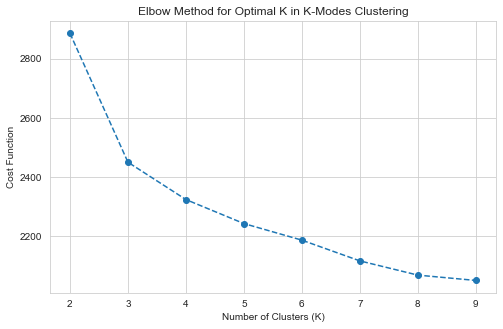

In [173]:
# Plot the Elbow Method (cost function plot)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(K_range, costs, marker="o", linestyle="dashed")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Cost Function")
plt.title("Elbow Method for Optimal K in K-Modes Clustering")
plt.savefig("elbowmethod.png", dpi=300, bbox_inches='tight')
plt.show()

In [174]:
# Function to calculate categorical silhouette score
def categorical_silhouette_score(X, labels):
    unique_labels = np.unique(labels)
    silhouette_scores = []
    
    for i, label in enumerate(labels):
        same_cluster = X[labels == label]
        other_clusters = X[labels != label]
        
        if len(same_cluster) > 1:
            a = np.mean([np.sum(same_cluster != row) for row in same_cluster])  # Intra-cluster distance
            b = np.min([np.mean(np.sum(other_clusters != row, axis=1)) for row in same_cluster])  # Nearest cluster distance
            silhouette_scores.append((b - a) / max(a, b))
    
    return np.mean(silhouette_scores) if silhouette_scores else -1

In [175]:
# Function to calculate Dunn Index
def dunn_index(X, labels):
    unique_labels = np.unique(labels)
    intra_distances = []
    inter_distances = []

    for label in unique_labels:
        cluster_points = X[labels == label]
        if len(cluster_points) > 1:
            intra_distances.append(np.mean([np.sum(cluster_points != row) for row in cluster_points]))

    for i, label_i in enumerate(unique_labels):
        cluster_i = X[labels == label_i]
        for j, label_j in enumerate(unique_labels):
            if i != j:
                cluster_j = X[labels == label_j]
                inter_distances.append(np.mean([np.sum(cluster_i != row) for row in cluster_j]))

    return min(inter_distances) / max(intra_distances) if intra_distances and inter_distances else -1

In [176]:
from sklearn.metrics import calinski_harabasz_score

In [177]:
# Convert dataframe to NumPy array for processing
X_encoded = encoded_df.to_numpy()

# Store results
silhouette_scores = []
dunn_indices = []
calinski_harabasz_scores = []
K_range = range(2, 10)

# Compute scores for different cluster sizes
for K in K_range:
    km = KModes(n_clusters=K, init='Huang', n_init=5, verbose=0)
    labels = km.fit_predict(X_encoded)

    # Compute evaluation metrics
    silhouette_scores.append(categorical_silhouette_score(X_encoded, labels))
    dunn_indices.append(dunn_index(X_encoded, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_encoded, labels))

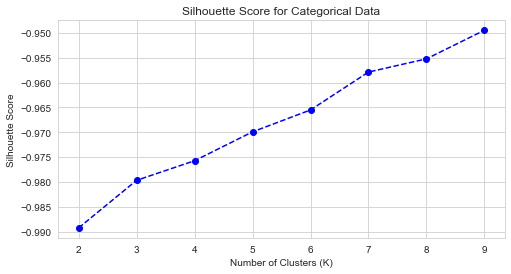

In [178]:
# Plot Silhouette Score
plt.figure(figsize=(8, 4))
plt.plot(K_range, silhouette_scores, marker="o", linestyle="dashed", color="blue")
plt.title("Silhouette Score for Categorical Data")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.savefig("silhouette_score.png", dpi=300, bbox_inches='tight')
plt.show()

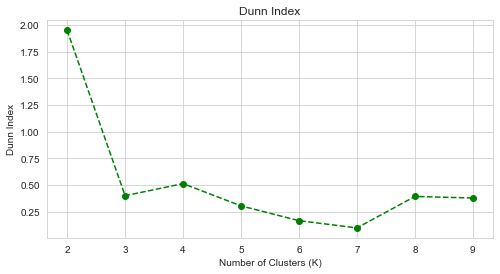

In [179]:
# Plot Dunn Index
plt.figure(figsize=(8, 4))
plt.plot(K_range, dunn_indices, marker="o", linestyle="dashed", color="green")
plt.title("Dunn Index")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Dunn Index")
plt.savefig("dunnindex.png", dpi=300, bbox_inches='tight')
plt.show()

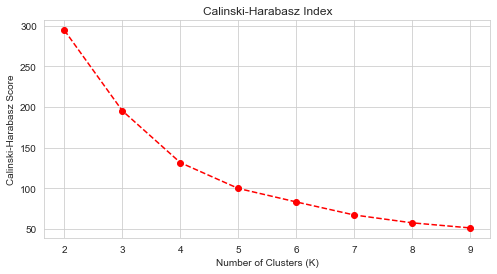

In [180]:
# Plot Calinski-Harabasz Index
plt.figure(figsize=(8, 4))
plt.plot(K_range, calinski_harabasz_scores, marker="o", linestyle="dashed", color="red")
plt.title("Calinski-Harabasz Index")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.savefig("calinski_score.png", dpi=300, bbox_inches='tight')
plt.show()

In [181]:
from kmodes.kmodes import KModes

# Perform K-Modes clustering with K = 4
k = 4
kmodes_model = KModes(n_clusters=k, init="Huang", n_init=5, verbose=1)
cluster_labels = kmodes_model.fit_predict(encoded_df)

# Add cluster labels to the original dataset
preprocessed_data["Cluster"] = cluster_labels

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 98, cost: 2336.0
Run 1, iteration: 2/100, moves: 7, cost: 2321.0
Run 1, iteration: 3/100, moves: 0, cost: 2321.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 98, cost: 2360.0
Run 2, iteration: 2/100, moves: 15, cost: 2329.0
Run 2, iteration: 3/100, moves: 13, cost: 2329.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 71, cost: 2391.0
Run 3, iteration: 2/100, moves: 4, cost: 2391.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 95, cost: 2394.0
Run 4, iteration: 2/100, moves: 22, cost: 2336.0
Run 4, iteration: 3/100, moves: 0, cost: 2336.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 203, cost: 2388.0
Run 5, iteratio

In [182]:
# Summarize cluster sizes
cluster_summary = preprocessed_data["Cluster"].value_counts()
cluster_summary

2    147
1    140
3     56
0     41
Name: Cluster, dtype: int64

In [183]:
preprocessed_data.head()

,customerid,age,gender,district,monthly_income,ridehailing_app,p_pickmepreference,p_pickmepurpose,p_pickmefrequency,p_pickmevehicle,...,b_switchingfrequency,b_purpose,b_frequency,b_time,b_pickmevehicle,b_ubervehicle,b_paymentmethod,b_pickmepass,b_uberone,Cluster
0,1,18-25,male,colombo,"lkr 50,000 – 99,999",both pickme & uber,NaN,NaN,NaN,NaN,...,often,"comfort and convenience, lack of public transp...",weekly,don't have a specific time,tuk,"tuk, moto",both cash & card,yes,no,1
1,2,18-25,female,colombo,"lkr 50,000 – 99,999",both pickme & uber,NaN,NaN,NaN,NaN,...,rarely,emergencies,occasionally,don't have a specific time,tuk,tuk,both cash & card,no,no,1
2,3,18-25,female,colombo,"lkr 100,000 – 149,999",both pickme & uber,NaN,NaN,NaN,NaN,...,often,"lack of public transport options, special occa...",occasionally,don't have a specific time,tuk,tuk,cash,no,no,1
3,4,under 18,female,colombo,"less than lkr 50,000",both pickme & uber,NaN,NaN,NaN,NaN,...,often,"comfort and convenience, shopping errands, sch...",monthly,don't have a specific time,"tuk, bike",tuk,cash,no,no,1
4,5,18-25,female,colombo,"less than lkr 50,000",both pickme & uber,NaN,NaN,NaN,NaN,...,rarely,emergencies,occasionally,don't have a specific time,tuk,tuk,cash,no,no,1


In [184]:
from sklearn.decomposition import PCA

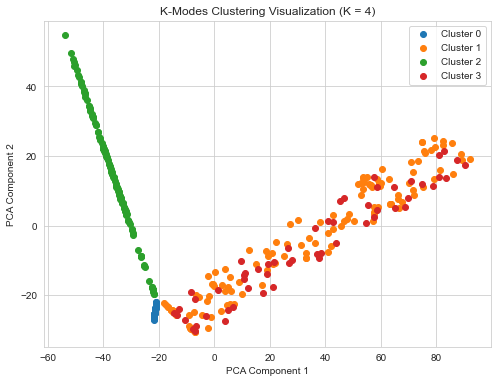

In [185]:
# Reduce dimensions using PCA for visualization
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(encoded_df)

# Plot the clusters
plt.figure(figsize=(8, 6))
for cluster in range(k):
    plt.scatter(reduced_data[cluster_labels == cluster, 0],
                reduced_data[cluster_labels == cluster, 1],
                label=f"Cluster {cluster}")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Modes Clustering Visualization (K = 4)")
plt.legend()
plt.savefig("k-mode.png", dpi=300, bbox_inches='tight')
plt.show()